In [1]:
%run ../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.pipelines.resnet50_pipeline import resnet50


In [3]:
builder = DatasetBuilder(DATASET_PATH)
task_name= "multiclase" 
task_config= TASKS[task_name]
df = builder.build(classes=task_config["classes"])
resnet50_model= resnet50(df, Case.IMAGE)
all_results = []

Use weighted cross entropy: True

EXPERIMENTO K-FOLD: resnet50_multiclase
Total images: 397
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 278 images (215 cálculos)
  Val:   42 images (35 cálculos)
  Test:  77 images (62 cálculos)
Device: cuda
Trainable parameters: 526,341
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=1.5943 acc=0.3493 f1=0.3829 | val: loss=1.5342 acc=0.3810 f1=0.3848 | lr=1.00e-04 | 7.9s
Epoch   2/30 | train: loss=1.3122 acc=0.4743 f1=0.5014 | val: loss=1.3217 acc=0.5238 f1=0.5040 | lr=1.00e-04 | 8.2s
Epoch   3/30 | train: loss=1.1440 acc=0.6103 f1=0.6261 | val: loss=1.2509 acc=0.5238 f1=0.5161 | lr=1.00e-04 | 8.1s
Epoch   4/30 | train: loss=1.1066 acc=0.6654 f1=0.6735 | val: loss=1.2182 acc=0.4762 f1=0.4646 | lr=1.00e-04 | 7.6s
Epoch   5/30 | train: loss=0.9795 acc=0.6544 f1=0.6600 | val: loss=1.1372 acc=0.4762 f1=0.4504 | lr=1.00e-04 | 7.9s
Epoch   6/30 | train: loss=0.9742 acc=0.6471 f1=0.6603 | val: loss=1.1021 

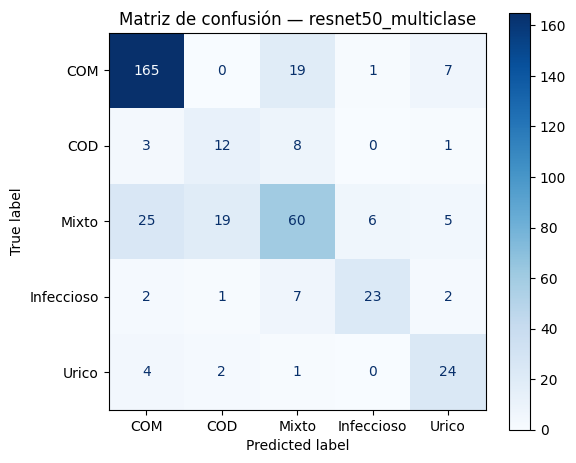


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7150 ± 0.0414
  auc_weighted: 0.9012 ± 0.0239
  f1_weighted: 0.7114 ± 0.0483
  precision_weighted: 0.7438 ± 0.0509
  recall_weighted: 0.7150 ± 0.0414


In [4]:

config = {
    "name": f"resnet50_{task_name}",
    "output_dir": f"experiments/resnet50/resnet50_images/resnet50_{task_name}",
    "class_names": task_config["class_names"],
    "batch_size": 8
}
result = resnet50_model.run_model(config, show_fold_metrics= True, use_weighted_cross_entropy= True)
all_results.append(result)
